Section 0: The Kagglehub Handshake

In [10]:
import kagglehub
import os

# 1. Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Base path:", path)

# 2. Define global paths (This fixes your NameError)
# Kagglehub structure is usually: path/chest_xray/train
base_dir = os.path.join(path, 'chest_xray')

# Check if the 'chest_xray' folder exists inside the path
if not os.path.exists(base_dir):
    base_dir = path

train_path = os.path.join(base_dir, 'train')
test_path = os.path.join(base_dir, 'test')
val_path = os.path.join(base_dir, 'val')

print(f"Train Path: {train_path}")
print(f"Test Path: {test_path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Base path: /kaggle/input/chest-xray-pneumonia
Train Path: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test Path: /kaggle/input/chest-xray-pneumonia/chest_xray/test


Path Configuration and loading images to view

Image shape: (1248, 1458)
Image shape: (720, 952)


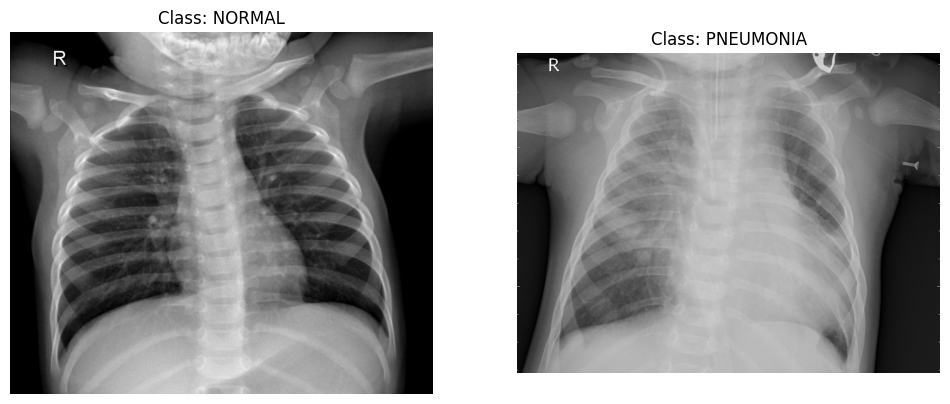

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_images(target_dir, target_class):
    # Setup target directory
    target_folder = os.path.join(target_dir, target_class)

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)

    # Read and plot image
    img = mpimg.imread(os.path.join(target_folder, random_image[0]))
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {target_class}")
    plt.axis("off")
    print(f"Image shape: {img.shape}")
    return img

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
view_random_images(train_path, "NORMAL")
plt.subplot(1, 2, 2)
view_random_images(train_path, "PNEUMONIA")
plt.show()

Section 1: Data Preprocessing & The "Real" Validation Split

In [12]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training Set (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Validation Set (20% - much more stable than the 16-image folder!)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Test Set
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Section 2: The Model Evolution Factory

In [13]:
from tensorflow.keras import layers, models, regularizers, optimizers

def build_pneumonia_architecture(level='basic', dropout_rate=0.5, l2_reg=0.001):
    """Handles only the building of layers."""
    model = models.Sequential(name=f"Pneumonia_{level}_Model")

    # Preprocessing
    model.add(layers.Input(shape=(150, 150, 3)))
    model.add(layers.Rescaling(1./255))

    # --- LEVEL 1: BASIC ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # --- LEVEL 2: MEDIUM ---
    if level in ['medium', 'advanced']:
        model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))

    # --- LEVEL 3: ADVANCED ---
    if level == 'advanced':
        model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                                kernel_regularizer=regularizers.l2(l2_reg)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

    # Classifier Head
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

def compile_and_fit(model, train_ds, val_ds, learning_rate=0.001, epochs=15):
    """Handles the tuning and execution logic."""

    # Pass learning rate ONLY to the optimizer here
    opt = optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall()])

    # Use EarlyStopping to catch the "weird" loss spikes automatically
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop]
    )
    return history

Section 3: The Evaluation Pipeline

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, name, history):
    print(f"\n Evaluating Model: {name}")

    # 1. Plot Trends using the history object
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    # 2. Test Evaluation (Ensure test_ds is loaded before this runs!)
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred = (model.predict(test_ds) > 0.5).astype("int32")

    print(f"\n {name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.title(f'{name} Confusion Matrix')
    plt.show()

Section 4: Step-by-Step Growth Execution

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8402 - loss: 0.6439 - recall_1: 0.9341 - val_accuracy: 0.9444 - val_loss: 0.1458 - val_recall_1: 0.9852
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9212 - loss: 0.1876 - recall_1: 0.9641 - val_accuracy: 0.9703 - val_loss: 0.0993 - val_recall_1: 0.9765
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9523 - loss: 0.1320 - recall_1: 0.9781 - val_accuracy: 0.9722 - val_loss: 0.0773 - val_recall_1: 0.9728
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9621 - loss: 0.1107 - recall_1: 0.9834 - val_accuracy: 0.9770 - val_loss: 0.0735 - val_recall_1: 0.9864
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9696 - loss: 0.0894 - recall_1: 0.9879 - val_accuracy: 0.9818 - val_loss: 0.0556 - val_recall_1: 0.9889
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9753 - loss: 0.0777 - recall_1: 0.9863 - val_accuracy: 0.9770 - val_loss: 0.06

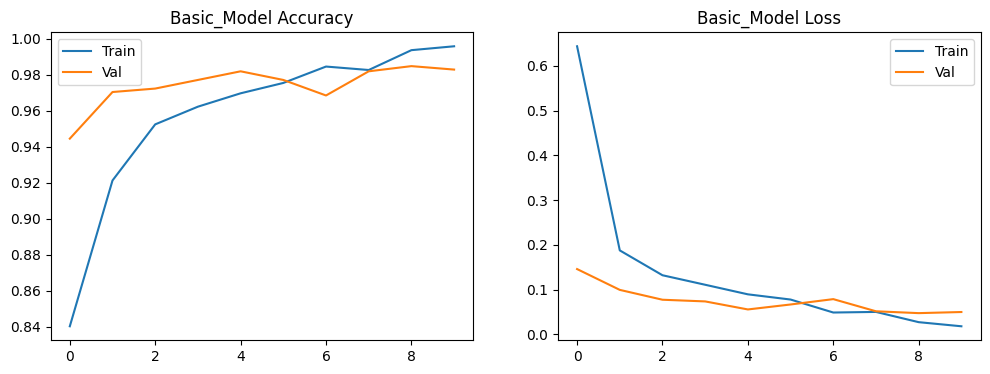

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step

 Basic_Model Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.30      0.46       234
   Pneumonia       0.70      0.99      0.82       390

    accuracy                           0.74       624
   macro avg       0.84      0.65      0.64       624
weighted avg       0.80      0.74      0.69       624



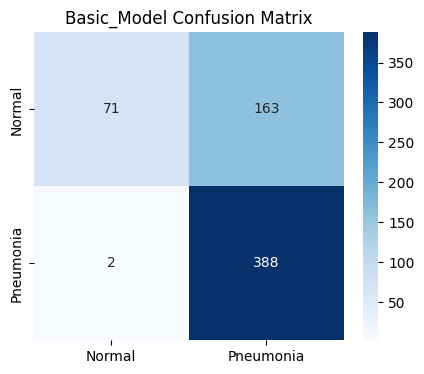

In [17]:
# 3.1 Basic Model (The Baseline)
# --- 1. BASIC MODEL ---
model_basic = build_pneumonia_architecture(level='basic', dropout_rate=0.2)
history_basic = compile_and_fit(model_basic, train_ds, val_ds, learning_rate=0.001, epochs=10)

evaluate_model(model_basic, "Basic_Model", history_basic)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.8883 - loss: 0.2629 - recall_2: 0.9449 - val_accuracy: 0.9597 - val_loss: 0.0961 - val_recall_2: 0.9679
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9514 - loss: 0.1280 - recall_2: 0.9680 - val_accuracy: 0.9636 - val_loss: 0.0784 - val_recall_2: 0.9840
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9633 - loss: 0.0973 - recall_2: 0.9752 - val_accuracy: 0.9693 - val_loss: 0.0739 - val_recall_2: 0.9827
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9688 - loss: 0.0856 - recall_2: 0.9788 - val_accuracy: 0.9732 - val_loss: 0.0722 - val_recall_2: 0.9889
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9741 - loss: 0.0701 - recall_2: 0.9830 - val_accuracy: 0.9789 - val_loss: 0.0660 - val_recall_2: 0.9840
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9796 - loss: 0.0556 - recall_2: 0.9850 - val_accuracy: 0.9751 - val_loss: 0.0

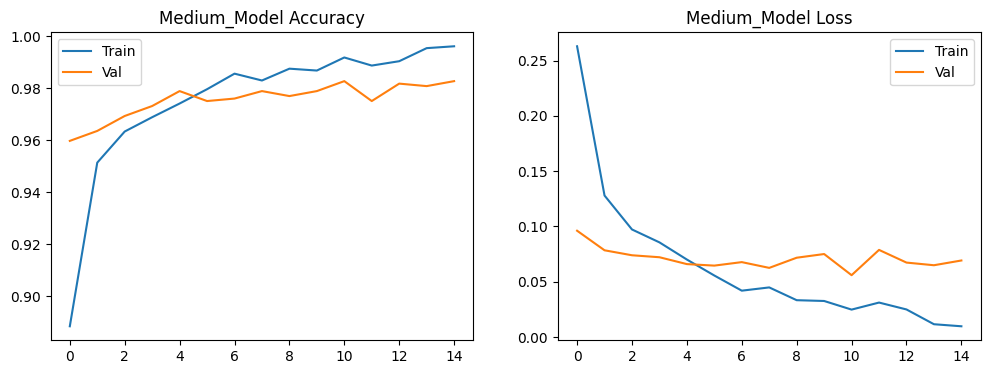

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step

 Medium_Model Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.31      0.47       234
   Pneumonia       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.84      0.65      0.65       624
weighted avg       0.81      0.74      0.69       624



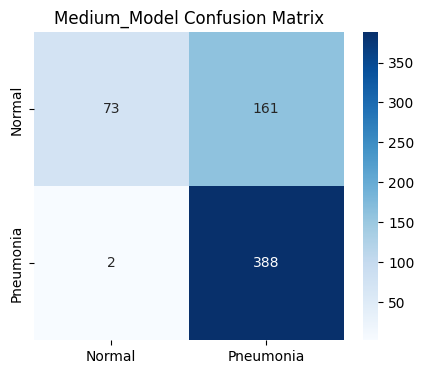

In [18]:
# Parameters: Mid complexity, slightly lower LR for stability

model_med = build_pneumonia_architecture(level='medium', dropout_rate=0.4)
history_med = compile_and_fit(model_med, train_ds, val_ds, learning_rate=0.0005, epochs=15)

evaluate_model(model_med, "Medium_Model", history_med)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.9003 - loss: 0.2589 - recall_3: 0.9468 - val_accuracy: 0.9060 - val_loss: 0.6118 - val_recall_3: 0.8790
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9578 - loss: 0.1288 - recall_3: 0.9710 - val_accuracy: 0.9722 - val_loss: 0.4167 - val_recall_3: 0.9704
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9684 - loss: 0.0986 - recall_3: 0.9778 - val_accuracy: 0.9847 - val_loss: 0.2057 - val_recall_3: 0.9840
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9712 - loss: 0.0859 - recall_3: 0.9804 - val_accuracy: 0.9837 - val_loss: 0.0940 - val_recall_3: 0.9901
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9751 - loss: 0.0782 - recall_3: 0.9821 - val_accuracy: 0.9837 - val_loss: 0.0649 - val_recall_3: 0.9852
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9818 - loss: 0.0673 - recall_3: 0.9866 - val_accuracy: 0.9732 - val_loss: 0.0

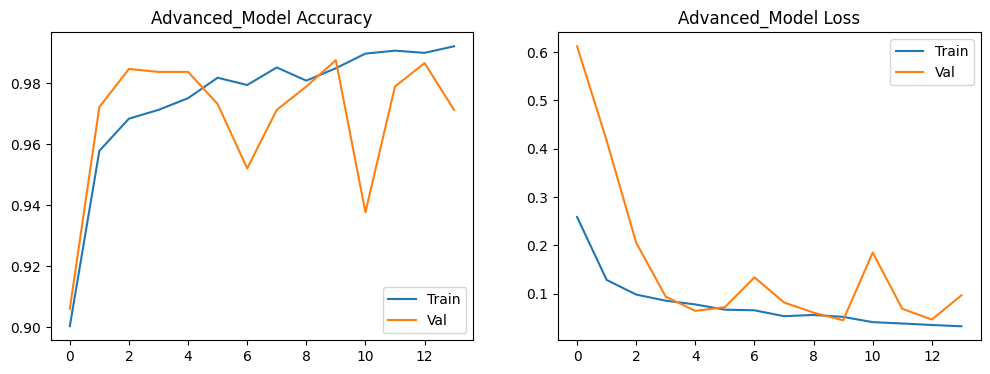

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step

 Advanced_Model Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.34      0.50       234
   Pneumonia       0.72      1.00      0.83       390

    accuracy                           0.75       624
   macro avg       0.86      0.67      0.67       624
weighted avg       0.82      0.75      0.71       624



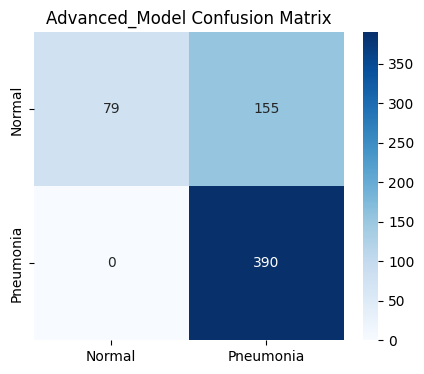

In [19]:

# 3.3 Advanced Model (Hyper-Tuned with Regularization)

# Parameters: Max complexity, High Dropout, Low L2, Slow LR
model_adv = build_pneumonia_architecture(level='advanced', dropout_rate=0.6, l2_reg=0.0001)

history_adv = compile_and_fit(model_adv, train_ds, val_ds, learning_rate=0.0001, epochs=20)

evaluate_model(model_adv, "Advanced_Model", history_adv)

This section is testing with different Threshold Values and see how does the Cofusion Matrix update specifically Normal-Normal.

Extracting actual labels from test_ds...
Generating predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step

Classification Report (Threshold = 0.8):
              precision    recall  f1-score   support

      Normal       0.96      0.44      0.60       234
   Pneumonia       0.75      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.85      0.71      0.73       624
weighted avg       0.83      0.78      0.76       624



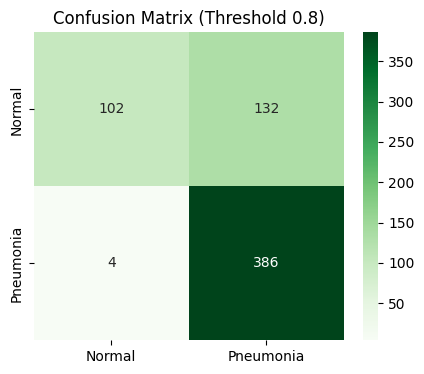

In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Extracting actual labels from test_ds...")
# 1. Recreate y_true in the global scope (this extracts the actual labels)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 2. Get raw probabilities (numbers between 0 and 1)
print("Generating predictions...")
y_probabilities = model_adv.predict(test_ds)

# 3. Test a new, stricter threshold
NEW_THRESHOLD = 0.8
y_pred_adjusted = (y_probabilities > NEW_THRESHOLD).astype("int32")

# 4. View the improved results
print(f"\nClassification Report (Threshold = {NEW_THRESHOLD}):")
print(classification_report(y_true, y_pred_adjusted, target_names=['Normal', 'Pneumonia']))

# 5. Plot the new Confusion Matrix
cm_adjusted = confusion_matrix(y_true, y_pred_adjusted)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title(f'Confusion Matrix (Threshold {NEW_THRESHOLD})')
plt.show()

Transfer Learning Approach with DenseNet121 model.

In [21]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

def build_transfer_model(dropout_rate=0.5):
    print("Downloading pre-trained DenseNet121 weights...")

    # 1. Load the giant pre-trained model (without its original classifier head)
    base_model = DenseNet121(
        weights='imagenet',       # Use weights trained on millions of images
        include_top=False,        # Chop off the final classification layer
        input_shape=(150, 150, 3)
    )

    # 2. FREEZE the base model! We don't want to destroy its learned features
    base_model.trainable = False

    # 3. Build our new hybrid model
    model = models.Sequential(name="DenseNet_Transfer_Model")

    # Ensure input shape is defined
    model.add(layers.Input(shape=(150, 150, 3)))

    # Preprocessing specific to DenseNet
    model.add(layers.Lambda(tf.keras.applications.densenet.preprocess_input))

    # Add the frozen DenseNet brain
    model.add(base_model)

    # Add our custom Pneumonia classification head
    model.add(layers.GlobalAveragePooling2D()) # Shrinks the output map gracefully
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Transfer Learning Model...
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 72s 346ms/step - accuracy: 0.9032 - loss: 0.2512 - recall_4: 0.9383 - val_accuracy: 0.9578 - val_loss: 0.1008 - val_recall_4: 0.9617
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9461 - loss: 0.1340 - recall_4: 0.9625 - val_accuracy: 0.9674 - val_loss: 0.0842 - val_recall_4: 0.9852
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9492 - loss: 0.1242 - recall_4: 0.9664 - val_accuracy: 0.9607 - val_loss: 0.0973 - val_recall_4: 0.9938
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9576 - loss: 0.1071 - recall_4: 0.9719 - val_accuracy: 0.9741 - val_loss: 0.0720 - val_recall_4: 0.9802
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9609 - loss: 0.1013 - recall_4: 0.9729 - val_accuracy: 0.9521 - val_loss: 0.1273 - val_recall_4: 0.9432
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - a

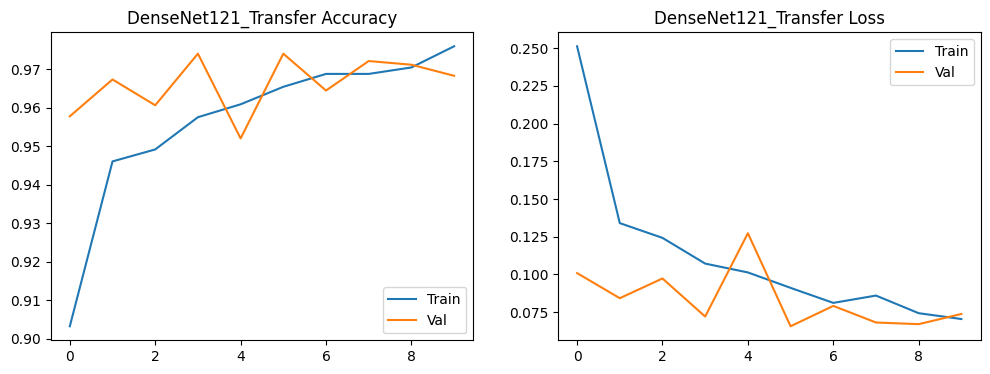

20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 962ms/step

 DenseNet121_Transfer Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.48      0.64       234
   Pneumonia       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624



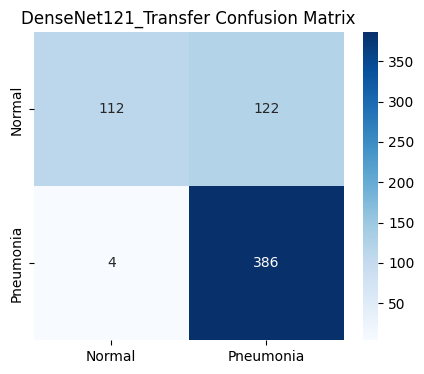

In [22]:
# 1. Build the Transfer Learning model
model_transfer = build_transfer_model(dropout_rate=0.4)

# 2. Train it (Notice we can use a slightly higher learning rate now because the base is frozen)
print("Training Transfer Learning Model...")
history_transfer = compile_and_fit(
    model_transfer,
    train_ds,
    val_ds,
    learning_rate=0.001,
    epochs=15
)

# 3. Evaluate the results
evaluate_model(model_transfer, "DenseNet121_Transfer", history_transfer)

Evaluating different thresholds for Confusion Matrix

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ensure we have the actual labels and the predicted probabilities
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_probabilities = model_transfer.predict(test_ds)

# 2. Define the thresholds we want to test
thresholds_to_test = [0.5, 0.6, 0.7, 0.8]

for t in thresholds_to_test:
    print(f"\n" + "="*40)
    print(f"TESTING THRESHOLD: {t}")
    print("="*40)

    # Apply the threshold
    y_pred_t = (y_probabilities > t).astype("int32")

    # Generate Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    print(f"True Negatives (Healthy predicted correctly): {tn}")
    print(f"False Positives (Healthy predicted as sick):  {fp}")
    print(f"False Negatives (Sick predicted as healthy):  {fn}")
    print(f"True Positives (Sick predicted correctly):    {tp}")
    print("-" * 40)

    # Print the precision and recall
    print(classification_report(y_true, y_pred_t, target_names=['Normal', 'Pneumonia']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step

TESTING THRESHOLD: 0.5
True Negatives (Healthy predicted correctly): 112
False Positives (Healthy predicted as sick):  122
False Negatives (Sick predicted as healthy):  4
True Positives (Sick predicted correctly):    386
----------------------------------------
              precision    recall  f1-score   support

      Normal       0.97      0.48      0.64       234
   Pneumonia       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624


TESTING THRESHOLD: 0.6
True Negatives (Healthy predicted correctly): 124
False Positives (Healthy predicted as sick):  110
False Negatives (Sick predicted as healthy):  5
True Positives (Sick predicted correctly):    385
----------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      0.53      0.68       2